In [1]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats


In [12]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [13]:
#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

In [2]:
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [5]:
icd_cat = set([i[0] for i in allsources_icd_gene_dict_unified.keys()])

In [15]:
#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)


In [16]:
#Let's create a network that takes into account the shared genetic component of these diseases


dis_gene_overlap_pval_dict={}

for dis1,genelist1 in allsources_icd_gene_dict_unified.items():
    for dis2,genelist2 in allsources_icd_gene_dict_unified.items():
        if dis1!=dis2:
            pval_ov=float(overlap_genelists(genelist1,genelist2,24008)) #24008 is the total number of genes
            dis_gene_overlap_pval_dict[dis1,dis2]=pval_ov

In [17]:
len(dis_gene_overlap_pval_dict)

1045506

In [18]:

dis_gene_overlap_fdr_dict={}
dis_gene_overlap_sigfdr_dict={}

adj_pval=fdr_adjustment(list(dis_gene_overlap_pval_dict.values()),0.05)
pair_list=list(dis_gene_overlap_pval_dict.keys())
for i in range(len(adj_pval)):
    dis_gene_overlap_fdr_dict[pair_list[i]]=adj_pval[i]
        
for dispair,fdr in dis_gene_overlap_fdr_dict.items():
    if fdr<0.05:
        dis_gene_overlap_sigfdr_dict[dispair]=fdr
    
print(len(dis_gene_overlap_sigfdr_dict))

224680


In [19]:
#Let's define the odds ratio between two genesets
def oddsratio(set1,set2,background):
    from scipy.stats import fisher_exact
    
    intersect = len(set1 & set2)
    set1_diff = len(set1) - intersect
    set2_diff = len(set2) - intersect
    background_diff = background - len(set1) - len(set2) + intersect
    
    # Create contingency table
    contingency_table = [[intersect, set1_diff], [set2_diff, background_diff]]
    
    # Perform Fisher's exact test
    oddsratio = fisher_exact(contingency_table)[0]
    
    return oddsratio

In [20]:
import math
G_gene_icd = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
for dis_pair,fdr in dis_gene_overlap_sigfdr_dict.items():
    rr_weight= oddsratio(allsources_icd_gene_dict_unified[dis_pair[0]],allsources_icd_gene_dict_unified[dis_pair[1]],G_ppi.number_of_nodes())
    G_gene_icd.add_edge(dis_pair[0], dis_pair[1], weight=rr_weight)

G_gene_icd.number_of_nodes()
G_gene_icd.number_of_edges()

112340

In [21]:
#Let's do it with the Jaccard Index

def jaccard_index(set1,set2):
    intersect = len(set1 & set2)
    union = len(set1.union(set2))
    ratio = intersect/union
    return ratio

G_gene_icd = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
for dis_pair,fdr in dis_gene_overlap_sigfdr_dict.items():
    ji_weight= jaccard_index(allsources_icd_gene_dict_unified[dis_pair[0]],allsources_icd_gene_dict_unified[dis_pair[1]])
    G_gene_icd.add_edge(dis_pair[0], dis_pair[1], weight=ji_weight)

G_gene_icd.number_of_nodes()
G_gene_icd.number_of_edges()

112340

In [22]:
#The resulted network is a little bit too dense, so I will use a disparity filter for reducing the number of edges
from scipy import integrate
#Here we define the disparity filter for backboning our future networks.
def disparity_filter(G, weight='weight'):
    ''' Compute significance scores (alpha) for weighted edges in G as defined in Serrano et al. 2009
        Args
            G: Weighted NetworkX graph
        Returns
            Weighted graph with a significance score (alpha) assigned to each edge
        References
            M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''
    if nx.is_directed(G): #directed case
        N = nx.DiGraph()
        for u in G:
            k_out = G.out_degree(u)
            k_in = G.in_degree(u)
            if k_out > 1:
                sum_w_out = sum(np.absolute(G[u][v][weight]) for v in G.successors(u))
                for v in G.successors(u):
                    w = G[u][v][weight]
                    p_ij_out = float(np.absolute(w))/sum_w_out
                    alpha_ij_out = 1 - (k_out-1) * integrate.quad(lambda x: (1-x)**(k_out-2), 0, p_ij_out)[0]
                    N.add_edge(u, v, weight = w, alpha_out=float('%.4f' % alpha_ij_out))
            elif k_out == 1 and G.in_degree(G.successors(u)[0]) == 1:
                #we need to keep the connection as it is the only way to maintain the connectivity of the network
                v = G.successors(u)[0]
                w = G[u][v][weight]
                N.add_edge(u, v, weight = w, alpha_out=0., alpha_in=0.)
                #there is no need to do the same for the k_in, since the link is built already from the tail
            if k_in > 1:
                sum_w_in = sum(np.absolute(G[v][u][weight]) for v in G.predecessors(u))
                for v in G.predecessors(u):
                    w = G[v][u][weight]
                    p_ij_in = float(np.absolute(w))/sum_w_in
                    alpha_ij_in = 1 - (k_in-1) * integrate.quad(lambda x: (1-x)**(k_in-2), 0, p_ij_in)[0]
                    N.add_edge(v, u, weight = w, alpha_in=float('%.4f' % alpha_ij_in))
        return N
    else: #undirected case
        B = nx.Graph()
        for u in G:
            k = len(G[u])
            if k > 1:
                sum_w = sum(np.absolute(G[u][v][weight]) for v in G[u])
                for v in G[u]:
                    w = G[u][v][weight]
                    p_ij = float(np.absolute(w))/sum_w
                    alpha_ij = 1 - (k-1) * integrate.quad(lambda x: (1-x)**(k-2), 0, p_ij)[0]
                    B.add_edge(u, v, weight = w, alpha=float('%.4f' % alpha_ij))
        return B



In [23]:
#sparsifying the network by applying disparity filter
G_gene_icd_disp = disparity_filter(G_gene_icd)
#Let's filter until we keep all nodes (atoms) in our network
alpha_cutoff_list=[0.95,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.03,0.01]
alpha_nodes_dict={}
for alpha in alpha_cutoff_list:
    G_gene_icd_disp_significant = nx.Graph([(u, v, d) for u, v, d in G_gene_icd_disp.edges(data=True) if d['alpha'] < alpha])
    filtered_G_nodes=G_gene_icd_disp_significant.number_of_nodes()
    filtered_G_edges=G_gene_icd_disp_significant.number_of_edges()
    alpha_nodes_dict[str(alpha)]=[filtered_G_nodes,filtered_G_edges]
    


In [24]:
alpha_nodes_dict

{'0.95': [1013, 107415],
 '0.9': [1013, 97280],
 '0.8': [1013, 81586],
 '0.7': [1013, 68138],
 '0.6': [1013, 55721],
 '0.5': [1013, 44259],
 '0.4': [1009, 32437],
 '0.3': [1004, 23541],
 '0.2': [995, 16293],
 '0.1': [965, 9396],
 '0.05': [917, 5925],
 '0.03': [892, 4628],
 '0.01': [825, 3535]}

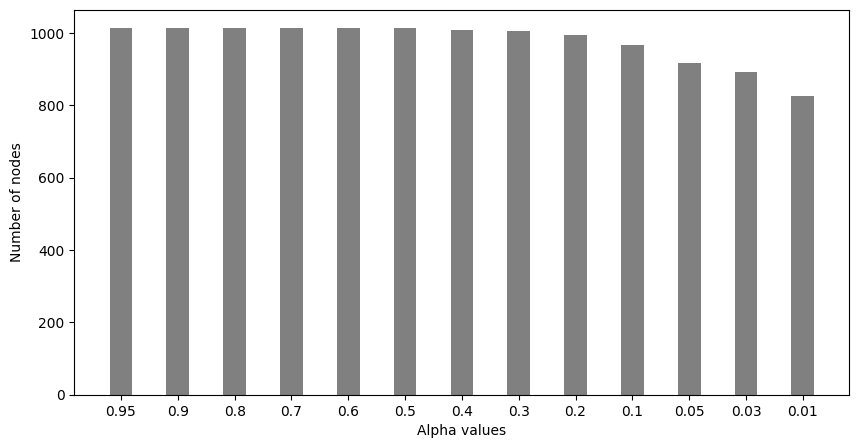

In [28]:

alpha_values = list(alpha_nodes_dict.keys())
nodes = list(i[0] for i in alpha_nodes_dict.values())
 
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(alpha_values, nodes, color ='grey', 
        width = 0.4)

plt.xlabel("Alpha values")
plt.ylabel("Number of nodes")
plt.savefig('Figures/Supplementary_Genetic_Network_aplha_thresholds_nodes.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

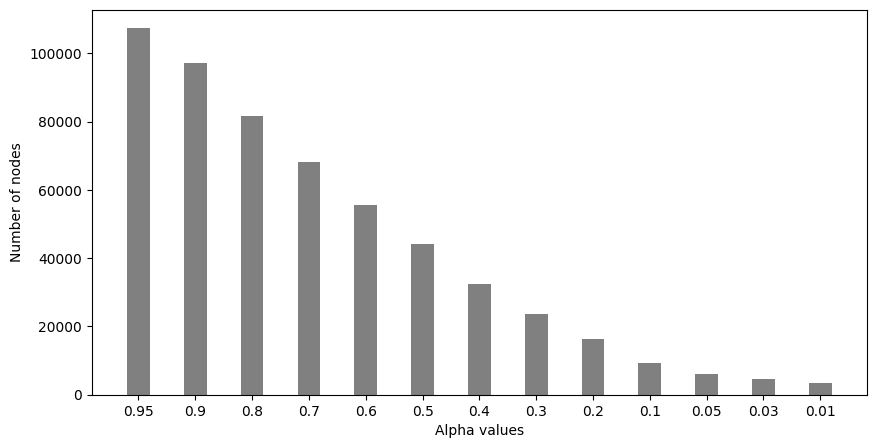

In [29]:
alpha_values = list(alpha_nodes_dict.keys())
edges = list(i[1] for i in alpha_nodes_dict.values())
 
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(alpha_values, edges, color ='grey', 
        width = 0.4)

plt.xlabel("Alpha values")
plt.ylabel("Number of nodes")
plt.savefig('Figures/Supplementary_Genetic_Network_aplha_thresholds_edges.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [30]:
G_gene_icd_disp = disparity_filter(G_gene_icd)
G_gene_icd_disp_significant_post = nx.Graph([(u, v, d) for u, v, d in G_gene_icd_disp.edges(data=True) if d['alpha'] < 0.3])
G_gene_icd_disp_significant_post.number_of_edges()


23541

In [31]:
G_gene_icd_disp_significant_post_df = nx.to_pandas_edgelist(G_gene_icd_disp_significant_post,'Dis A', 'Dis B')
G_gene_icd_disp_significant_post_df.to_csv('output/G_gene_icd_disp_significant_post_df.tsv', sep = '\t')


In [9]:
#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

In [32]:
#Let's extract the ICD categories
icd_cat = set([str(n[0]) for n in G_gene_icd_disp_significant_post.nodes()])

# Generate a color map with `len(elements)` unique colors
cmap = plt.get_cmap('tab20')  

# Function to convert RGBA to HEX
def rgba_to_hex(rgba):
    return '#{:02x}{:02x}{:02x}'.format(int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255))


# Ensure you have enough unique colors in the chosen colormap
num_colors = len(icd_cat)
colors = [cmap(i) for i in range(num_colors)]
# Convert colors to hex
hex_colors = [rgba_to_hex(color) for color in colors]

# Create a dictionary to map each element to a unique color
icd_cat_color_mapping = {elem: color for elem, color in zip(icd_cat, hex_colors)}



In [33]:
with open('output/icd_cat_color_mapping.pickle', 'wb') as handle:
    pk.dump(icd_cat_color_mapping, handle, protocol=pk.HIGHEST_PROTOCOL)

In [6]:
icd_cat_genedict = {}
for icd in icd_cat:
    genelist = []
    for icd_code,geneset in allsources_icd_gene_dict_unified.items():
        if icd in icd_code:
            genelist.extend(list(geneset))
    icd_cat_genedict[icd] = set(genelist)

for cat,geneset in icd_cat_genedict.items():
    print(cat,len(geneset))

Y 50
G 6533
K 8779
R 1114
Q 4243
L 4993
B 6174
S 122
M 5847
P 4062
N 5071
T 4015
D 7354
O 4152
X 5
A 6489
Z 64
J 5257
I 5767
H 4914
C 3207
U 160
E 6049
F 5961


In [35]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_gene_icd_disp_significant_post.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [38]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_gene_icd_disp_significant_post.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_86404/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_86404/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_86404/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [39]:
feature_df_T=feature_df.T

In [40]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_gene_icd_disp_significant_post, nodelist=list(G_gene_icd_disp_significant_post.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_gene_icd_disp_significant_post.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_gene_icd_disp_significant_post.nodes())
FM_structural.columns=list(G_gene_icd_disp_significant_post.nodes())
FM_structural

,B59,N80,J13,L80,M34,B26,D86,L40,D70,D45,...,A83,A92,B96,J93,J94,F14,F68,F69,D39,D40
B59,0.901343,0.001505,0.016371,0.001872,0.001414,0.031035,0.002566,0.001131,0.003509,0.001181,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
N80,0.000478,0.900174,0.000016,0.000025,0.001588,0.000017,0.000016,0.000023,0.000021,0.000001,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
J13,0.016029,0.000048,0.901310,0.001843,0.001514,0.030426,0.002542,0.001106,0.003421,0.001154,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
L80,0.000558,0.000023,0.000562,0.900200,0.001691,0.000038,0.000054,0.000030,0.000028,0.000009,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
M34,0.000702,0.002483,0.000767,0.002814,0.900173,0.000050,0.002716,0.000042,0.000034,0.000017,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.904762,0.047619,0.047619,0.000000,0.000000
F68,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.047619,0.904762,0.047619,0.000000,0.000000
F69,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.047619,0.047619,0.904762,0.000000,0.000000
D39,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.909091,0.090909


In [41]:
scalar_val = 0.95
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 15
spr = 2.5
md = 2.0
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_gene_icd_disp_significant_post,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/umap/umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
/opt/anaconda3/envs/Elma/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [42]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

#edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [43]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 3 #0.15
d_size = draw_node_degree(G_gene_icd_disp_significant_post, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

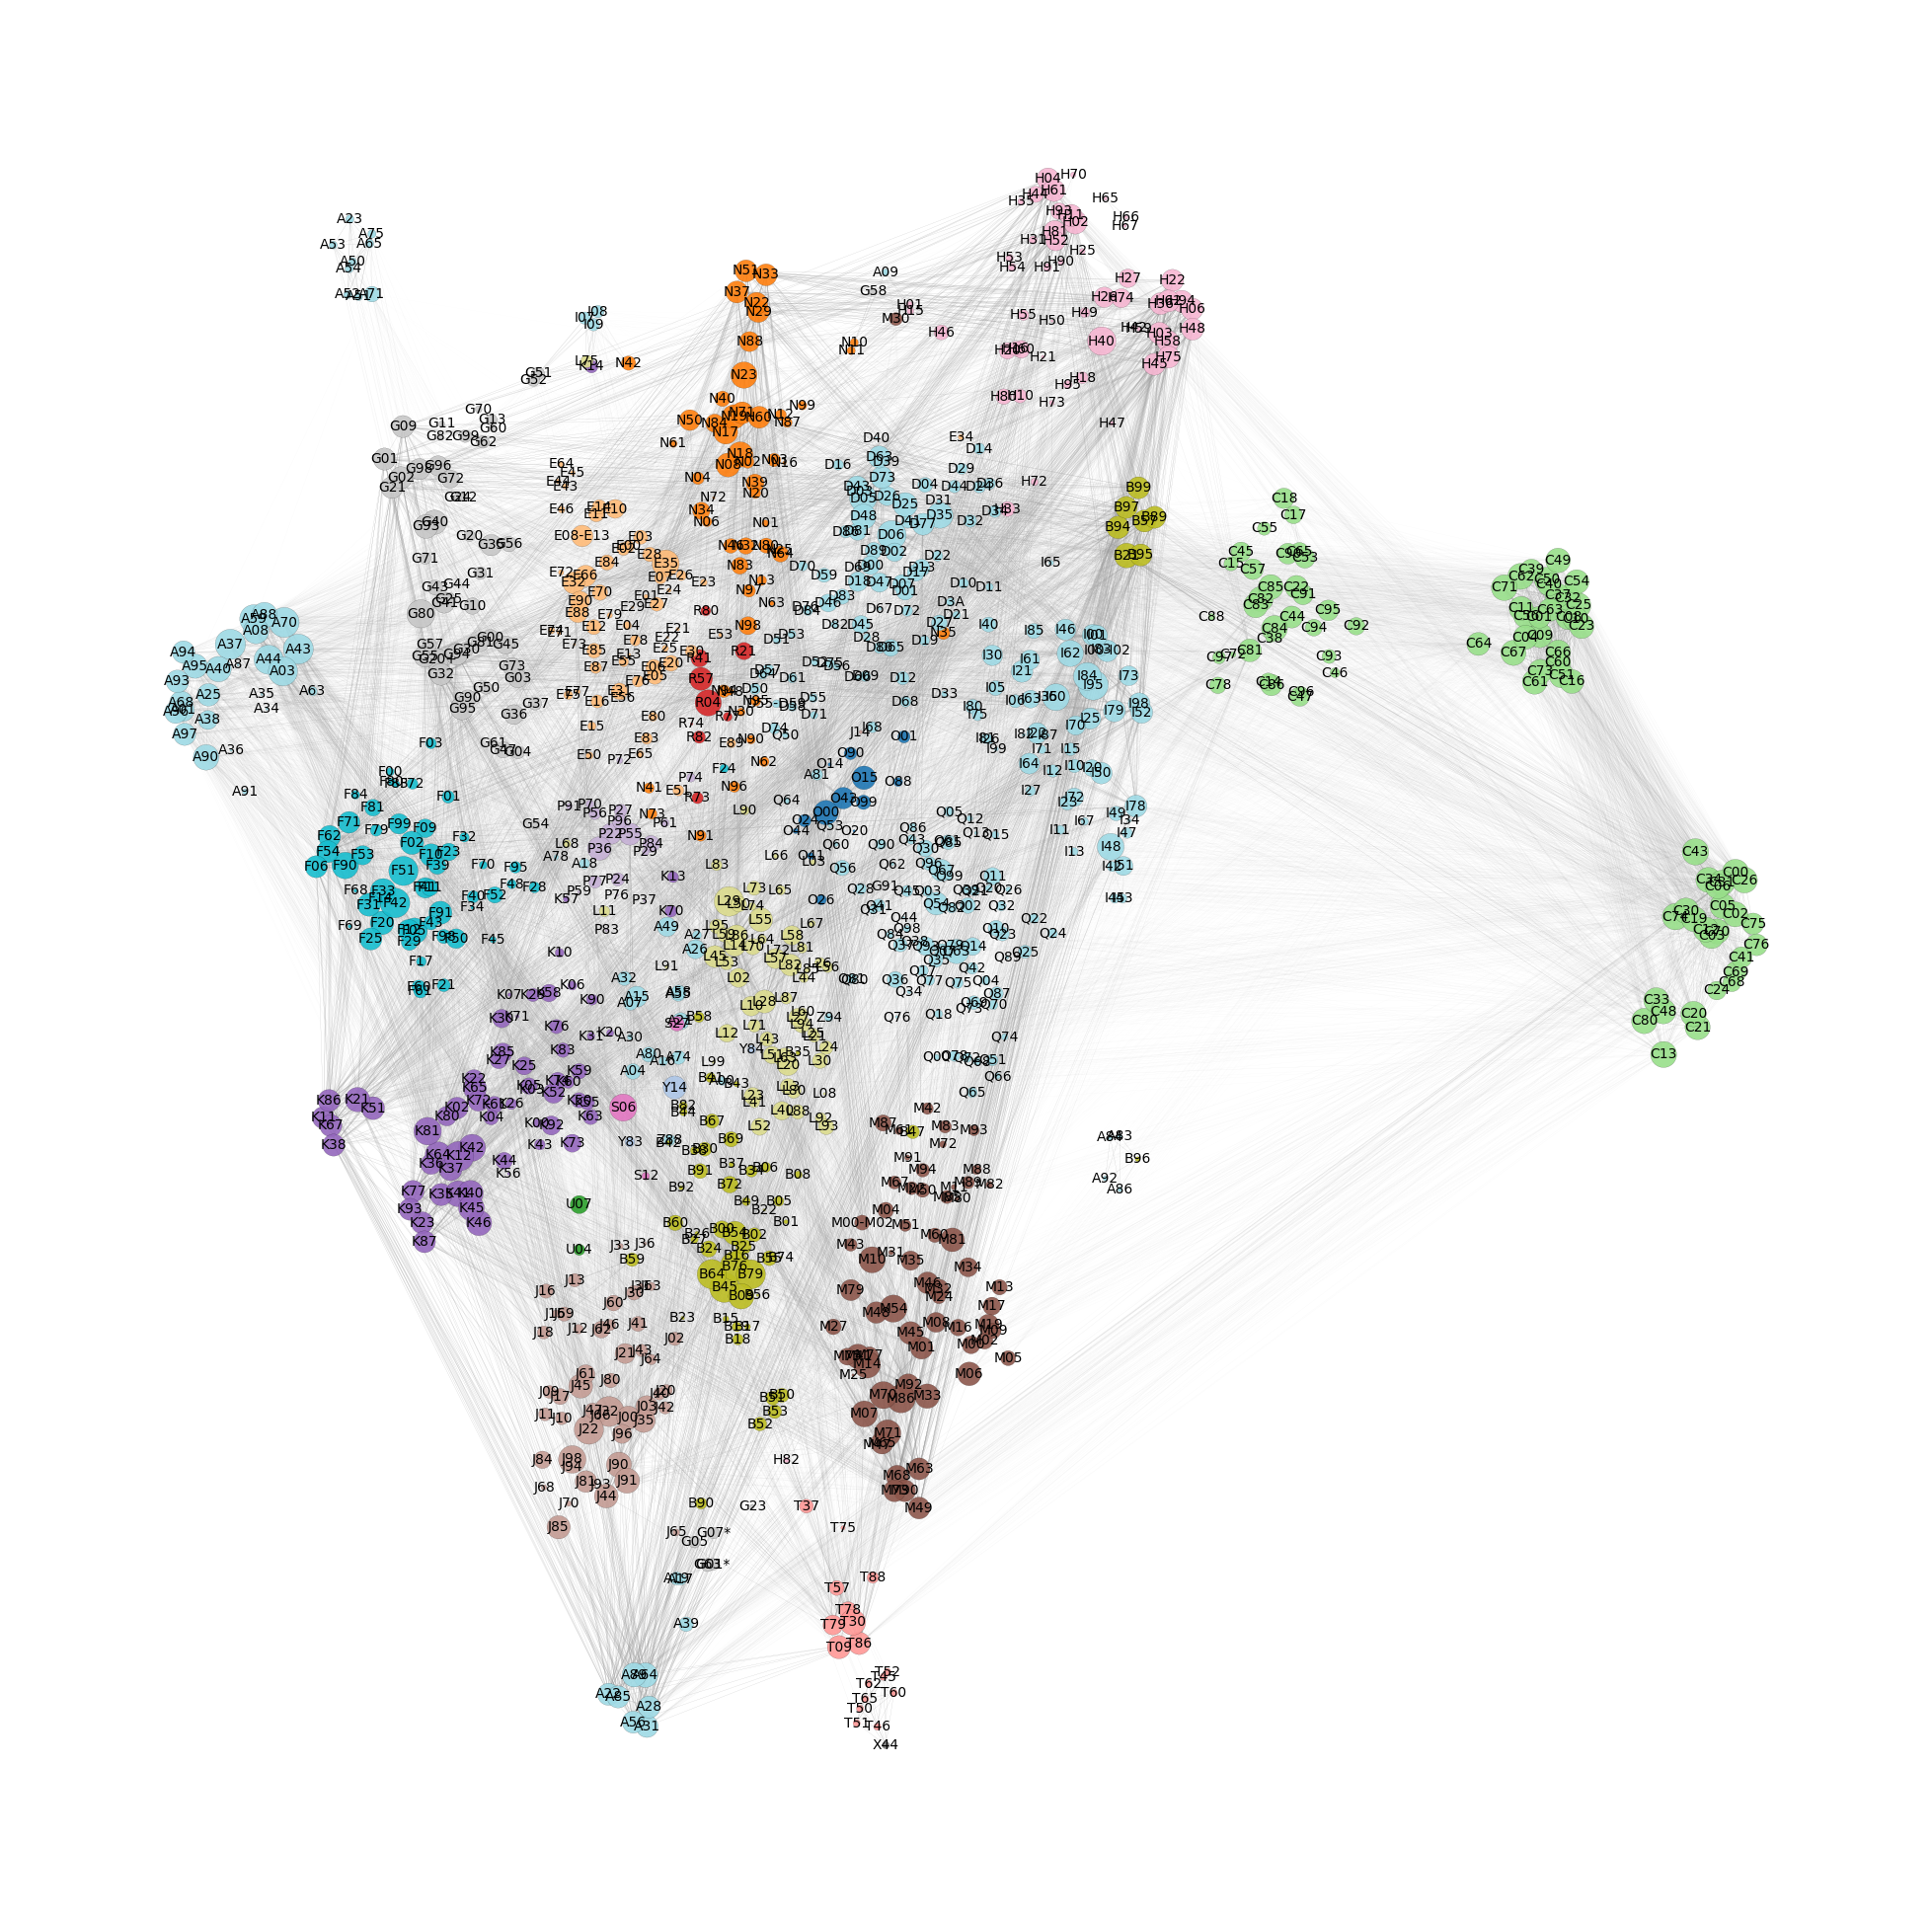

In [44]:
color_list = []
for node in posG2D_new.keys():
    color_list.append(icd_cat_color_mapping[node[0]])


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_gene_icd_disp_significant_post, 
                       posG2D_new,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = l_size, 
                       alpha = opacity_nodes)
widths = nx.get_edge_attributes(G_gene_icd_disp_significant_post, 'weight')
max_width = max(widths.values())
min_width = min(widths.values())

nx.draw_networkx_edges(G_gene_icd_disp_significant_post, posG2D_new,  width = edge_width, edge_color = edge_color, alpha = [i for i in list(widths.values())])
plt.box(False)
nx.draw_networkx_labels(G_gene_icd_disp_significant_post,pos=posG2D_new,font_size=10)
plt.savefig('Figures/Fig1D.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [10]:
G_gene_icd_disp_significant_post_degree=dict(nx.degree(G_gene_icd_disp_significant_post))
dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True))

{'A37': 162,
 'J32': 160,
 'I95': 160,
 'A43': 159,
 'A70': 158,
 'K12': 157,
 'B45': 156,
 'F42': 156,
 'L29': 156,
 'B76': 155,
 'F51': 152,
 'B64': 152,
 'J22': 152,
 'A44': 151,
 'B79': 151,
 'A03': 151,
 'D06': 148,
 'H40': 144,
 'A59': 143,
 'M86': 142,
 'G80': 140,
 'I84': 137,
 'J98': 135,
 'K81': 135,
 'M54': 131,
 'S06': 131,
 'D05': 130,
 'M70': 130,
 'E35': 130,
 'M14': 129,
 'K42': 129,
 'I60': 128,
 'I48': 127,
 'C00': 126,
 'M71': 125,
 'C43': 124,
 'F90': 124,
 'C74': 123,
 'I62': 123,
 'N23': 123,
 'R04': 122,
 'M10': 121,
 'C62': 120,
 'M07': 120,
 'C13': 120,
 'K64': 119,
 'K41': 119,
 'C71': 118,
 'C84': 118,
 'D35': 118,
 'F05': 118,
 'C26': 117,
 'T30': 117,
 'K45': 117,
 'K40': 116,
 'A90': 115,
 'C30': 115,
 'A88': 115,
 'B09': 115,
 'A08': 115,
 'A40': 114,
 'F33': 114,
 'C20': 114,
 'C80': 114,
 'C34': 113,
 'C31': 113,
 'K46': 113,
 'C33': 113,
 'C08': 112,
 'C25': 112,
 'C67': 112,
 'N18': 112,
 'J90': 112,
 'C05': 112,
 'C21': 112,
 'J91': 111,
 'C19': 111,

In [46]:
for n,weight_dict in dict(G_gene_icd_disp_significant_post['A37']).items():
    if weight_dict['weight']>0.5:
        print(n)

J32
J22
I95
L29


In [47]:
dict(G_gene_icd_disp_significant_post['A37'])['J32']

{'weight': 0.5733333333333334, 'alpha': 0.0095}

In [48]:
dict(G_gene_icd_disp_significant_post['A37'])['J22']

{'weight': 0.5194805194805194, 'alpha': 0.0147}

In [49]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_gene_icd_disp_significant_post)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

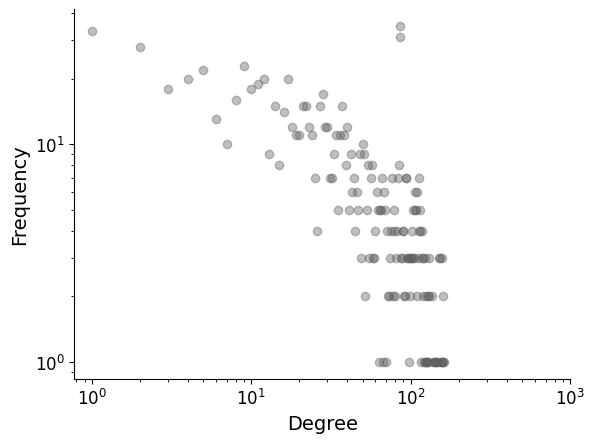

In [51]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100, 1000])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/GeneticNetwork_DegreeDistribution.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

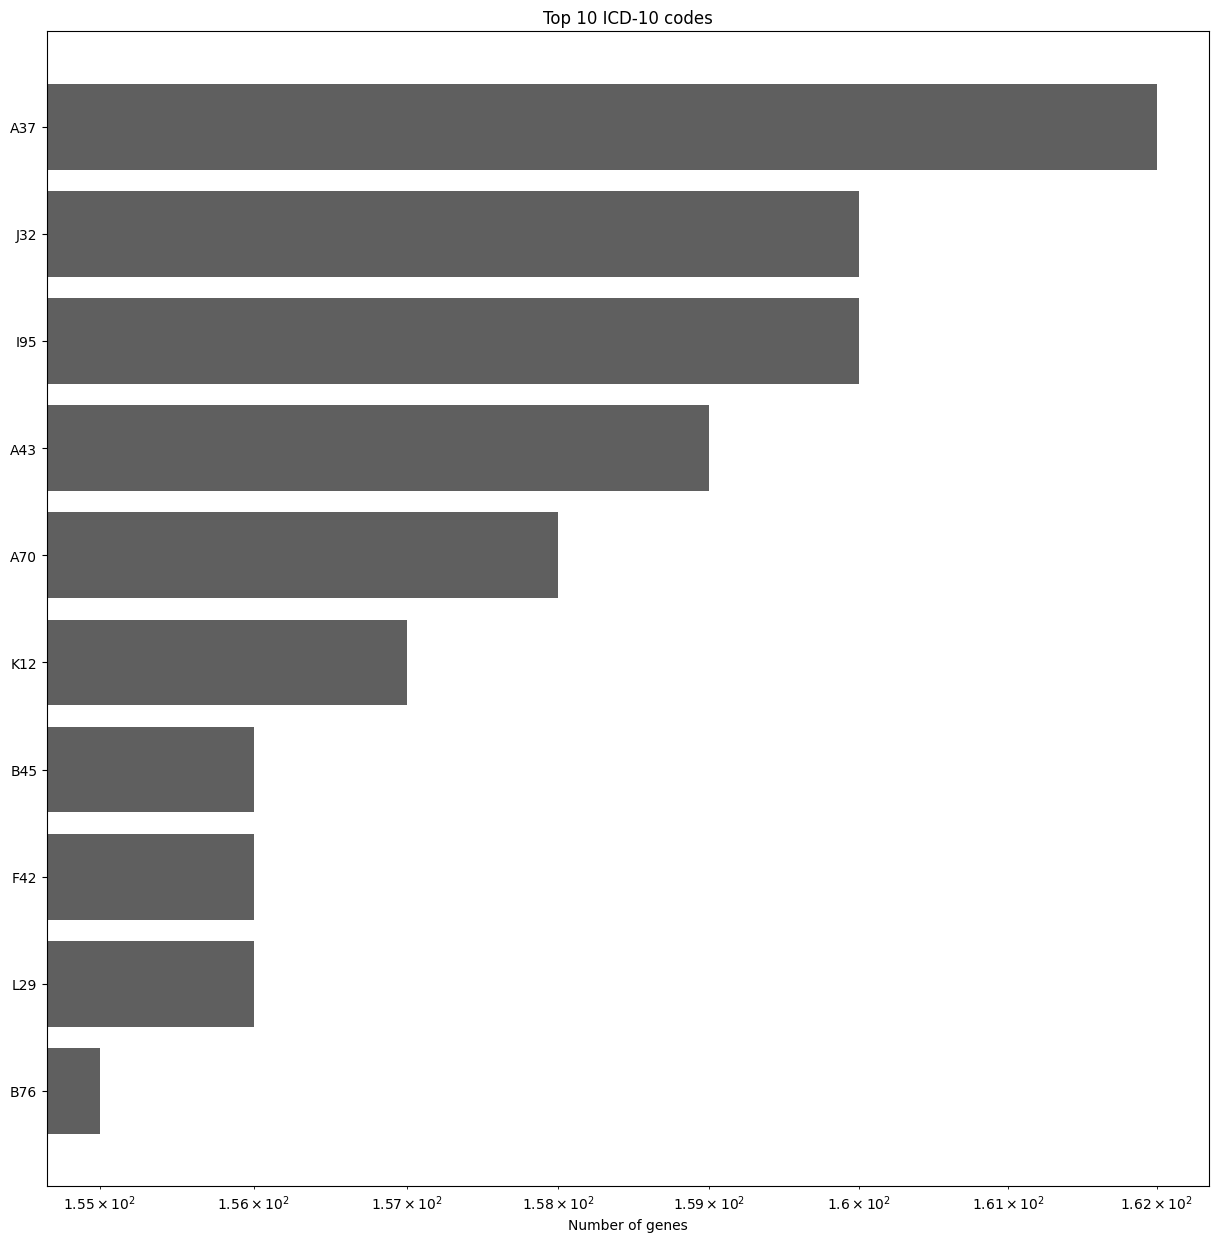

In [17]:
genelist_len = [G_gene_icd_disp_significant_post_degree[dis] for dis in list(dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True)).keys())[:10]] 

fig, ax = plt.subplots(figsize=(15,15))

y_pos = np.arange(10)

ax.barh(y_pos, genelist_len, align='center', color='#5F5F5F')
ax.set_yticks(y_pos, labels=list(dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True)).keys())[:10])
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes')

plt.savefig('Figures/SF2D_TopICD10codesdegree.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.savefig('Figures/SF2D_TopICD10codesdegree.png',format='pdf',dpi=300, bbox_inches = "tight") 
plt.show()



In [52]:
import community as community_louvain

def optimal_resolution(G, resolution_list,weight,random_state):
    """
    Param:
    G: A networkx graph
    resolution_list: List of resolution values to check
    """
    res_mod_dict = {}
    max_modularity = -1 # initialize maximum modularity as negative value
    for resolution in resolution_list:
        partition = community_louvain.best_partition(G, resolution=resolution,weight=weight,random_state=random_state)
        modularity = community_louvain.modularity(partition,G)
        res_mod_dict[resolution] = modularity

        if modularity > max_modularity:   # save the partition and resolution giving the maximum modularity
            max_modularity = modularity
            best_partition = partition
            best_resolution = resolution
            
    return best_partition, best_resolution, max_modularity,res_mod_dict

In [53]:
resolution_list = np.linspace(0.1, 2, 20) 

best_partition, best_resolution, max_modularity, res_mod_dict = optimal_resolution(G_gene_icd_disp_significant_post, resolution_list,'weight',5495)
print('Optimal resolution value: ', best_resolution)


Optimal resolution value:  0.7999999999999999


In [54]:
G_gene_icd_partition = community_louvain.best_partition(G_gene_icd_disp_significant_post,weight='weight',resolution=0.8)

In [55]:
len(set(G_gene_icd_partition.values()))

21

In [56]:
G_gene_icd_com={}

for com in set(G_gene_icd_partition.values()):
    dislist=[]
    for dis,comcom in G_gene_icd_partition.items():
        if com==comcom:
            dislist.append(dis)
    G_gene_icd_com[com]=dislist
    

In [58]:
with open('output/G_gene_icd_com.pickle', 'wb') as handle:
    pk.dump(G_gene_icd_com, handle, protocol=pk.HIGHEST_PROTOCOL)

In [59]:

G_gene_icd_ICD_partition = {}
for icd in icd_cat:
    dislist = []
    for node in G_gene_icd_disp_significant_post.nodes():
        if icd in node:
            dislist.append(node)
    G_gene_icd_ICD_partition[icd] = dislist


In [60]:
com_source=[]
com_target=[]
value_list=[]
com_label=list(G_gene_icd_ICD_partition.keys())+["Louvain_"+str(com2) for com2 in list(G_gene_icd_com.keys())]

for com1,dislist1 in G_gene_icd_ICD_partition.items():
    for com2,dislist2 in G_gene_icd_com.items():
        com1_name=str(com1)
        com2_name="Louvain_"+str(com2)
        com_source_index=com_label.index(com1_name)
        com_target_index=com_label.index(com2_name)
        for dis in dislist1:
            if dis in dislist2:
                com_source.append(com_source_index)
                com_target.append(com_target_index)
                value_list.append(1)
        #value_list.append(ov*10000)
        #value_list.append(10)



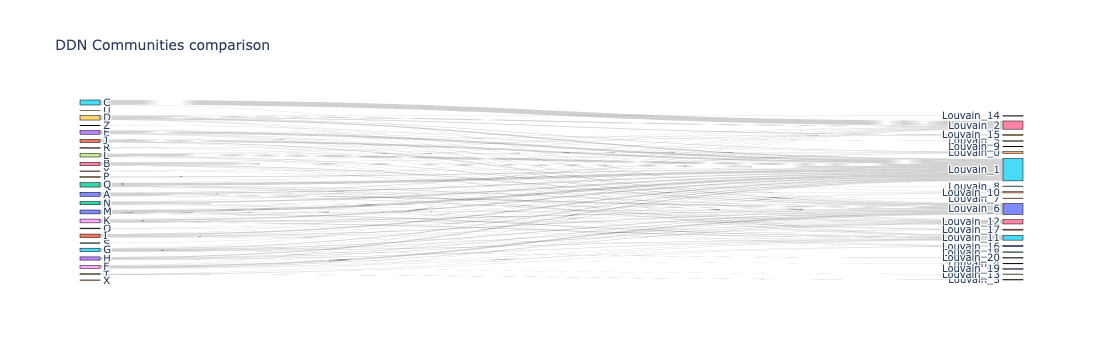

In [61]:
import plotly.graph_objects as go
import kaleido


fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = com_label,
    ),
    link = dict(
      source = com_source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = com_target,
      value = value_list,
      line = dict(color = "grey", width = 0.005),
        
  ))])
fig.update_layout(title_text="DDN Communities comparison", font_size=10)
fig.show()
fig.write_image("Figures/Fig2A.pdf", engine="kaleido")

In [62]:
for com1,dislist1 in G_gene_icd_ICD_partition.items():
    for com2,dislist2 in G_gene_icd_com.items():
        ov=float(overlap_jaccard(dislist1,dislist2))
        if ov>0.5:
            print(com1,com2,ov)



C 2 0.5714285714285714


In [63]:

louvain_cat_genedict = {}
for com_louvain,dislist in G_gene_icd_com.items():
    genelist = []
    for dis in dislist:
        genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
    louvain_cat_genedict[com_louvain] = set(genelist)
        
    

In [64]:
#Let's calculate the lcc z-score

#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z


In [65]:
icd_cat_genedict_lcc_dict = {}
louvain_cat_genedict_lcc_dict = {}

for com,geneset in icd_cat_genedict.items():
    icd_cat_genedict_lcc_dict[com] = net_modularity(geneset,G_ppi)
    
for com,geneset in louvain_cat_genedict.items():
    louvain_cat_genedict_lcc_dict[com] = net_modularity(geneset,G_ppi)

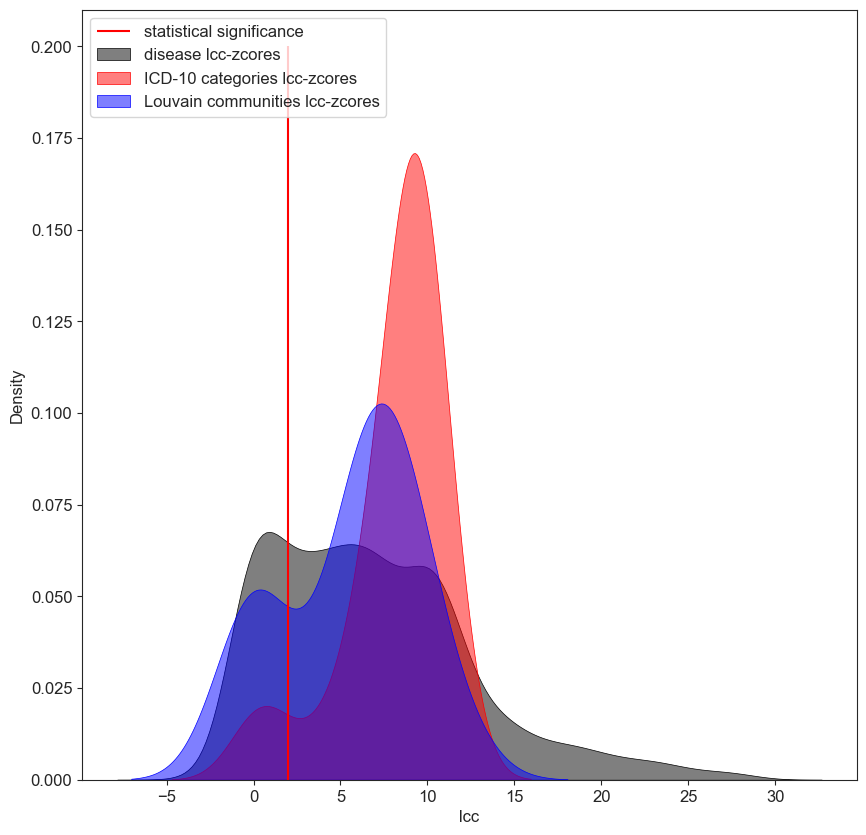

In [66]:
#Let's plot the distribution of all lcc z-scores

icd_lcc_zscores = [i for i in icd_cat_genedict_lcc_dict.values() if str(i)!='nan']
louvain_lcc_zscores = [i for i in louvain_cat_genedict_lcc_dict.values() if str(i)!='nan']
lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore.values() if str(i)!='nan']

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(2,ymin=0,ymax=0.2,color='r',label='statistical significance')
sns.kdeplot(lcc_zscores,color='k',lw=.5,alpha=.5,fill=True,label='disease lcc-zcores')
sns.kdeplot(icd_lcc_zscores,color='r',lw=.5,alpha=.5,fill=True,label='ICD-10 categories lcc-zcores')
sns.kdeplot(louvain_lcc_zscores,color='b',lw=.5,alpha=.5,fill=True,label='Louvain communities lcc-zcores')
plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('lcc',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/Fig2B.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [67]:
from scipy.stats import mannwhitneyu

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(louvain_lcc_zscores, icd_lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=112.5, pvalue=0.008844727288779714)

In [68]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(louvain_lcc_zscores, lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=7997.0, pvalue=0.5552381366277706)

In [69]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(icd_lcc_zscores, lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=14393.0, pvalue=0.04409368973507584)

In [72]:
np.median(icd_lcc_zscores)

9.057403457375077

In [73]:
np.median(louvain_lcc_zscores)

6.481502536538508